<a href="https://colab.research.google.com/github/Deeva2601/Python-ML-lab/blob/main/new_Laptop_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/laptop_data.csv")

In [3]:
df.shape

(893, 18)

In [4]:
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'brand', 'name', 'price', 'spec_rating',
       'processor', 'CPU', 'Ram', 'Ram_type', 'ROM', 'ROM_type', 'GPU',
       'display_size', 'resolution_width', 'resolution_height', 'OS',
       'warranty'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 893 entries, 0 to 892
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0.1       893 non-null    int64  
 1   Unnamed: 0         893 non-null    int64  
 2   brand              893 non-null    object 
 3   name               893 non-null    object 
 4   price              893 non-null    int64  
 5   spec_rating        893 non-null    float64
 6   processor          893 non-null    object 
 7   CPU                893 non-null    object 
 8   Ram                893 non-null    object 
 9   Ram_type           893 non-null    object 
 10  ROM                893 non-null    object 
 11  ROM_type           893 non-null    object 
 12  GPU                893 non-null    object 
 13  display_size       893 non-null    float64
 14  resolution_width   893 non-null    float64
 15  resolution_height  893 non-null    float64
 16  OS                 893 non

In [6]:
df.isnull().sum()

,0
Unnamed: 0.1,0
Unnamed: 0,0
brand,0
name,0
price,0
spec_rating,0
processor,0
CPU,0
Ram,0
Ram_type,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.drop(columns=['Unnamed: 0.1','Unnamed: 0'],inplace = True)

In [9]:
plt.figure(figsize=(8,6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

# EDA

In [10]:
df['price'].describe()

,price
count,893.000000
mean,79907.409854
std,60880.043823
min,9999.000000
25%,44500.000000
50%,61990.000000
75%,90990.000000
max,450039.000000


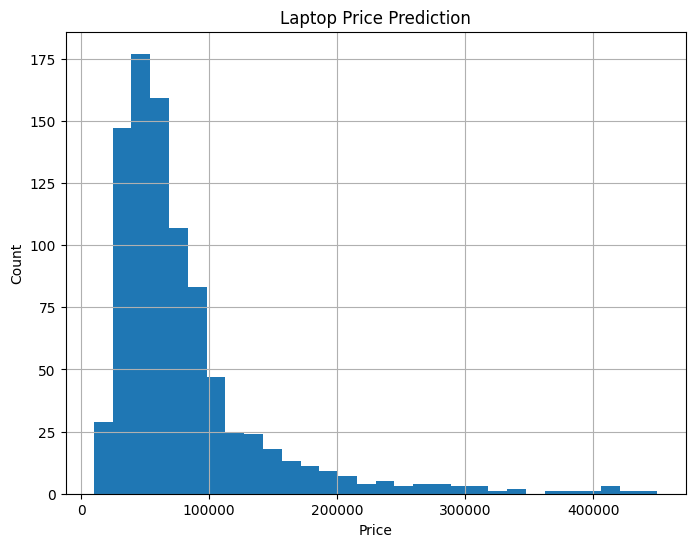

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
df['price'].hist(bins=30)
#plt.grid(False)
plt.xlabel('Price')
plt.ylabel('Count')
plt.title('Laptop Price Prediction')
plt.show()

In [12]:
df['price'].describe()

,price
count,893.000000
mean,79907.409854
std,60880.043823
min,9999.000000
25%,44500.000000
50%,61990.000000
75%,90990.000000
max,450039.000000


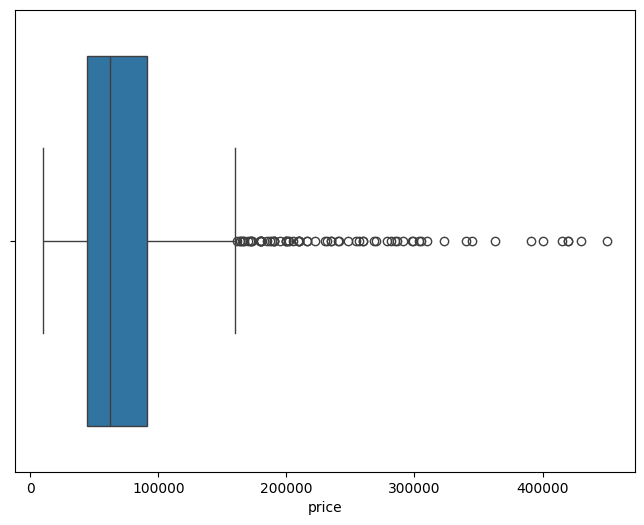

In [13]:
# Boxplot to find outlier

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.boxplot(x=df['price'])
plt.show()

In [14]:
#find outliers
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3-Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['price']<lower) | (df['price'] > upper)]
print('Outliers:' ,len(outliers))
print('Percentage', round(len(outliers)/len(df)*100,2),"%")
print("Upper Limit:", upper)

Outliers: 71
Percentage 7.95 %
Upper Limit: 160725.0


In [15]:
df[['brand','name','price']].sort_values(
    by='price',
    ascending = False
).head(10)

,brand,name,price
288,Dell,Alienware M18 R1 2023 Gaming Laptop,450039
181,Asus,ROG Zephyrus Duo 16,429990
346,MSI,Titan GT77 HX 13VH-093IN Gaming Laptop,420000
562,MSI,CreatorPro Z16 HX B13VKTO-214IN Laptop,419990
607,HP,Spectre 17-cs0097nr Foldable Laptop,415000
45,Lenovo,Legion 9i 2023 Laptop,399999
739,HP,ZBook Studio G9 2023 Workstation WQUXGA Laptop,390914
543,HP,Omen 17-ck2011TX Gaming Laptop,362999
698,MSI,Vector GP78HX 13VI-409IN Gaming Laptop,344990
441,Asus,ROG Zephyrus Duo 16 2022 GX650RXZ-LO227WS Gami...,339990


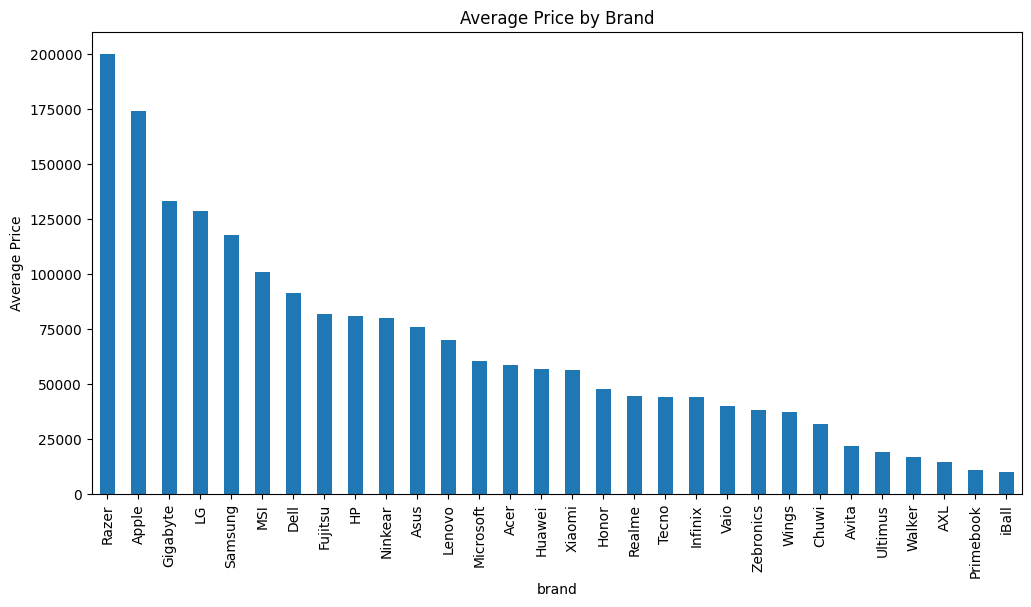

In [16]:
import matplotlib.pyplot as plt

brand_price =(
    df.groupby('brand')['price'].mean().sort_values(ascending=False)
)

plt.figure(figsize=(12,6))
brand_price.plot(kind='bar')
plt.title('Average Price by Brand')
plt.ylabel('Average Price')
plt.show()

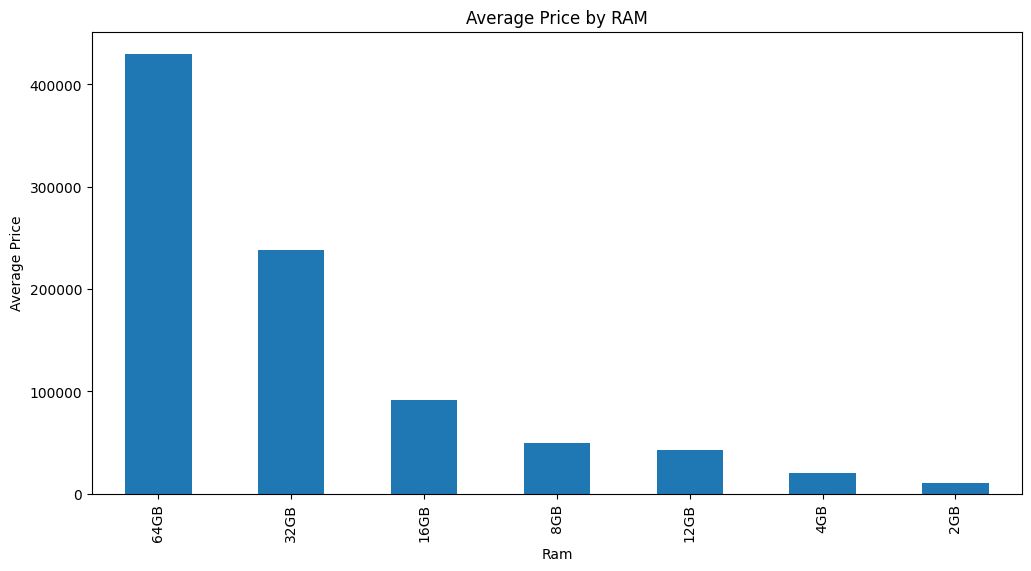

In [17]:
import matplotlib.pyplot as plt

ram_price = (
    df.groupby('Ram')['price'].mean().sort_values(ascending=False)
)
plt.figure(figsize=(12,6))
ram_price.plot(kind='bar')
plt.title('Average Price by RAM')
plt.ylabel('Average Price')
plt.show()

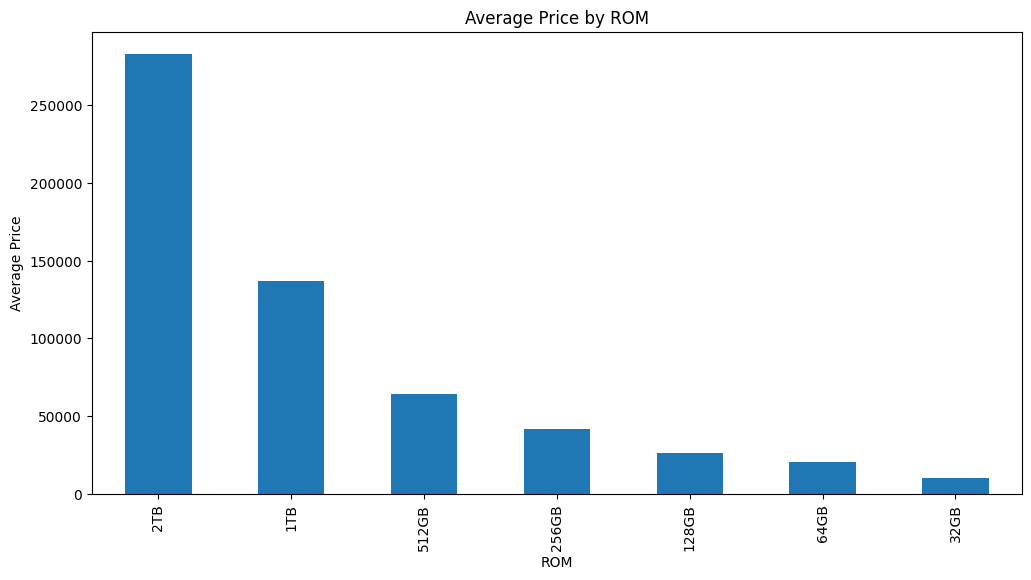

In [18]:
import matplotlib.pyplot as plt

row_price = (
    df.groupby('ROM')['price'].mean().sort_values(ascending=False)
)
plt.figure(figsize=(12,6))
row_price.plot(kind='bar')
plt.title('Average Price by ROM')
plt.ylabel('Average Price')
plt.show()

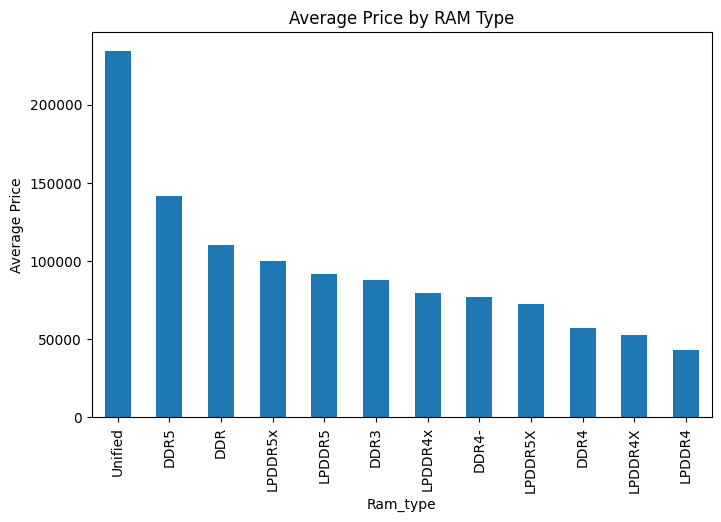

In [19]:
import matplotlib.pyplot as plt

ramtype_price = (
    df.groupby('Ram_type')['price'].mean().sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
ramtype_price.plot(kind='bar')
plt.title('Average Price by RAM Type')
plt.ylabel('Average Price')
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


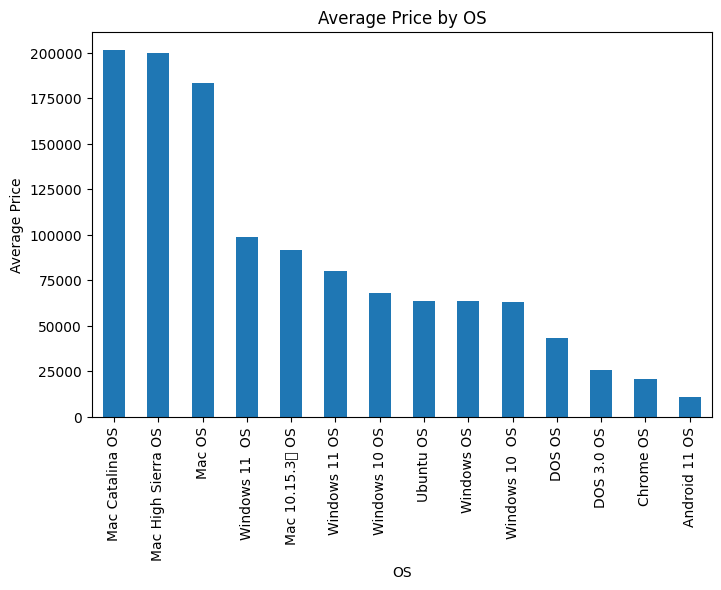

In [20]:
os_price = (
    df.groupby('OS')['price'].mean().sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
os_price.plot(kind='bar')
plt.title('Average Price by OS')
plt.ylabel('Average Price')
plt.show()

In [21]:
df[['Ram','ROM','warranty']].head()

,Ram,ROM,warranty
0,8GB,512GB,1
1,8GB,512GB,1
2,8GB,512GB,1
3,16GB,512GB,1
4,8GB,256GB,1


In [22]:
print(df['processor'].nunique())
print(df['GPU'].nunique())

184
134


In [23]:
df['Ram'].unique()

array(['8GB', '16GB', '4GB', '32GB', '2GB', '12GB', '64GB'], dtype=object)

Ram Conversion

In [24]:
df['Ram'] = df['Ram'].astype(str).str.replace('GB','',regex=False).astype(int)
df['Ram'].head()

,Ram
0,8
1,8
2,8
3,16
4,8


In [25]:
df['ROM'].unique()

array(['512GB', '256GB', '128GB', '64GB', '1TB', '32GB', '2TB'],
      dtype=object)

In [26]:
def convert_storage(x):
    if 'TB' in x:
        return int(x.replace('TB','')) * 1024
    else:
        return int(x.replace('GB',''))

df['ROM'] = df['ROM'].apply(convert_storage)

In [27]:
df['ROM'].head()

,ROM
0,512
1,512
2,512
3,512
4,256


In [28]:
df['processor'].sample(20,random_state=42)

,processor
710,13th Gen Intel Core i5 1340P
440,12th Gen Intel Core i5 1235U
525,7th Gen AMD Ryzen 5 7530U
721,12th Gen Intel Core i7 12700H
39,12th Gen Intel Core i5 12450H
290,13th Gen Intel Core i5 1335U
300,12th Gen Intel Core i3 1215U
333,13th Gen Intel Core i5 1335U
208,12th Gen Intel Core i5 12500H
136,Intel Celeron N4500


In [29]:
df['processor_brand'] = df['processor'].str.extract(
    r'(Intel|AMD)'
)[0].value_counts()

In [30]:
df['processor_series'] = df['processor'].str.extract(
    r'(i3|i5|i7|i9|Ryzen 3| Ryzen 5|Ryzen 7|Ryzen 9)'
)[0].value_counts()


In [31]:
df['GPU'].str.extract(
    r'(RTX|GTX|Randeon|Iris Xe|UHD)'
)[0].value_counts()

,count
0,
RTX,268
Iris Xe,196
UHD,168
GTX,28


In [32]:
df[df['GPU'].str.contains('Radeon',case=False,na=False)]['GPU'].head(20)

,GPU
0,4GB AMD Radeon RX 6500M
14,AMD Radeon Graphics
20,AMD Radeon Vega 7
24,AMD Radeon Vega 7
25,AMD Radeon AMD
32,4GB AMD Radeon RX 6500M Graphics
47,AMD Radeon Radeon Graphics
51,AMD Radeon Graphics
53,AMD Radeon Graphics
56,AMD Radeon AMD


In [33]:
df['processor_brand'] = df['processor'].str.extract('(Intel|AMD)', expand=False)

df['processor_series'] = df['processor'].str.extract(
    '(i3|i5|i7|i9|Ryzen 3|Ryzen 5|Ryzen 7|Ryzen 9|Celeron)',
    expand=False
)

In [34]:
df[['processor','processor_brand','processor_series']].head(15)

,processor,processor_brand,processor_series
0,5th Gen AMD Ryzen 5 5600H,AMD,Ryzen 5
1,12th Gen Intel Core i3 1215U,Intel,i3
2,11th Gen Intel Core i3 1115G4,Intel,i3
3,12th Gen Intel Core i5 1240P,Intel,i5
4,Apple M1,NaN,NaN
5,12th Gen Intel Core i5 1240P,Intel,i5
6,12th Gen Intel Core i3 1215U,Intel,i3
7,13th Gen Intel Core i5 13420H,Intel,i5
8,12th Gen Intel Core i5 12500H,Intel,i5
9,12th Gen Intel Core i5 1240P,Intel,i5


In [35]:
type(df['processor'].iloc[0])

str

In [36]:
df['processor_brand'].value_counts(dropna=False)

,count
processor_brand,
Intel,609
AMD,255
NaN,29


In [37]:
df['processor_series'].value_counts(dropna=False)

,count
processor_series,
i5,287
i7,148
Ryzen 5,128
i3,109
Ryzen 7,87
i9,36
Ryzen 3,34
NaN,28
Celeron,28


In [38]:
df[df['processor_brand'].isna()]['processor'].value_counts()

,count
processor,
11th Gen intel Core i3 1115G4,4
7th Gen Amd Ryzen 5 7535HS,4
Apple M2,3
Apple M1 Pro M1 Pro,3
7th Gen Amd Ryzen 5 7520U,2
Apple M1,1
MediaTek MTK8788,1
Apple M1 Apple M1 Chip,1
Apple M2 Max M2 Max,1


In [39]:
df['processor_brand'] = df['processor'].str.extract(
    r'(Intel|intel|AMD|Amd|Apple|MediaTek)',
    expand = False
)

In [40]:
df['processor_brand'] = df['processor_brand'].replace({
    'intel' : 'Intel',
    'Amd' : 'Amd'
})

In [41]:
df['processor_brand'].value_counts(dropna=False)

,count
processor_brand,
Intel,615
AMD,255
Apple,12
Amd,10
MediaTek,1


In [42]:
df['processor_brand'].value_counts()

,count
processor_brand,
Intel,615
AMD,255
Apple,12
Amd,10
MediaTek,1


In [43]:
def gpu_category(gpu):
  gpu = str(gpu)

  if 'RTX' in gpu:
    return 'RTX'
  elif 'GTX' in gpu:
    return 'GTX'
  elif 'Radeon' in gpu:
     return 'Radeon'
  elif 'Iris Xe' in gpu:
    return "Iris Xe"
  elif 'UHD' in gpu:
    return 'UHD'
  else:
    return 'Others'

df['gpu_category'] = df['GPU'].apply(gpu_category)

In [44]:
df['gpu_category'].value_counts()

,count
gpu_category,
RTX,268
Iris Xe,196
UHD,168
Radeon,168
Others,65
GTX,28


In [45]:
df.columns

Index(['brand', 'name', 'price', 'spec_rating', 'processor', 'CPU', 'Ram',
       'Ram_type', 'ROM', 'ROM_type', 'GPU', 'display_size',
       'resolution_width', 'resolution_height', 'OS', 'warranty',
       'processor_brand', 'processor_series', 'gpu_category'],
      dtype='object')

In [46]:
df['CPU'].head(10)

,CPU
0,"Hexa Core, 12 Threads"
1,"Hexa Core (2P + 4E), 8 Threads"
2,"Dual Core, 4 Threads"
3,"12 Cores (4P + 8E), 16 Threads"
4,Octa Core (4P + 4E)
5,"12 Cores (4P + 8E), 16 Threads"
6,"Hexa Core (2P + 4E), 8 Threads"
7,"Octa Core (4P + 4E), 12 Threads"
8,"12 Cores (4P + 8E), 16 Threads"
9,"12 Cores (4P + 8E), 16 Threads"


In [47]:
df['cores'] = df['CPU'].str.extract(r'(\d+)').astype(float)

In [48]:
df[['CPU','cores']].head(10)

,CPU,cores
0,"Hexa Core, 12 Threads",12.0
1,"Hexa Core (2P + 4E), 8 Threads",2.0
2,"Dual Core, 4 Threads",4.0
3,"12 Cores (4P + 8E), 16 Threads",12.0
4,Octa Core (4P + 4E),4.0
5,"12 Cores (4P + 8E), 16 Threads",12.0
6,"Hexa Core (2P + 4E), 8 Threads",2.0
7,"Octa Core (4P + 4E), 12 Threads",4.0
8,"12 Cores (4P + 8E), 16 Threads",12.0
9,"12 Cores (4P + 8E), 16 Threads",12.0


In [49]:
df.drop(columns=['name'],inplace=True)

In [50]:
df.select_dtypes(include='object').columns

Index(['brand', 'processor', 'CPU', 'Ram_type', 'ROM_type', 'GPU', 'OS',
       'processor_brand', 'processor_series', 'gpu_category'],
      dtype='object')

In [51]:
df['processor_series'] = df['processor_series'].fillna('Others')

In [52]:
df['processor_series'].isnull().sum()

np.int64(0)

In [53]:
df.columns

Index(['brand', 'price', 'spec_rating', 'processor', 'CPU', 'Ram', 'Ram_type',
       'ROM', 'ROM_type', 'GPU', 'display_size', 'resolution_width',
       'resolution_height', 'OS', 'warranty', 'processor_brand',
       'processor_series', 'gpu_category', 'cores'],
      dtype='object')

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 893 entries, 0 to 892
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              893 non-null    object 
 1   price              893 non-null    int64  
 2   spec_rating        893 non-null    float64
 3   processor          893 non-null    object 
 4   CPU                893 non-null    object 
 5   Ram                893 non-null    int64  
 6   Ram_type           893 non-null    object 
 7   ROM                893 non-null    int64  
 8   ROM_type           893 non-null    object 
 9   GPU                893 non-null    object 
 10  display_size       893 non-null    float64
 11  resolution_width   893 non-null    float64
 12  resolution_height  893 non-null    float64
 13  OS                 893 non-null    object 
 14  warranty           893 non-null    int64  
 15  processor_brand    893 non-null    object 
 16  processor_series   893 non

In [55]:
X = df.drop('price',axis=1)
y = np.log1p(df['price']) # Log transform y here, before train-test split

In [56]:
print(X.shape)
print(y.shape)

(893, 18)
(893,)


# Encoding

In [57]:
X = pd.get_dummies(X,drop_first=True)

In [58]:
X.shape

(893, 424)

In [59]:
X.head()

,spec_rating,Ram,ROM,display_size,resolution_width,resolution_height,warranty,cores,brand_Acer,brand_Apple,...,processor_series_Ryzen 9,processor_series_i3,processor_series_i5,processor_series_i7,processor_series_i9,gpu_category_Iris Xe,gpu_category_Others,gpu_category_RTX,gpu_category_Radeon,gpu_category_UHD
0,73.000000,8,512,15.6,1920.0,1080.0,1,12.0,False,False,...,False,False,False,False,False,False,False,False,True,False
1,60.000000,8,512,15.6,1920.0,1080.0,1,2.0,False,False,...,False,True,False,False,False,False,False,False,False,True
2,69.323529,8,512,14.0,1920.0,1080.0,1,4.0,True,False,...,False,True,False,False,False,True,False,False,False,False
3,66.000000,16,512,14.0,2240.0,1400.0,1,12.0,False,False,...,False,False,True,False,False,True,False,False,False,False
4,69.323529,8,256,13.3,2560.0,1600.0,1,4.0,False,True,...,False,False,False,False,False,False,True,False,False,False


Train_test_split

In [60]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)

(714, 424)
(179, 424)


# Linear Regression

In [61]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

# Impute missing values in the 'cores' column with the mean
X_train['cores'] = X_train['cores'].fillna(X_train['cores'].mean())
X_test['cores'] = X_test['cores'].fillna(X_test['cores'].mean())

lr.fit(X_train,y_train)

LinearRegression()

In [62]:
y_pred_log = lr.predict(X_test)

In [63]:
from sklearn.metrics import r2_score,mean_absolute_error

# Inverse transform predictions and actual values for evaluation on original scale
actual_lr_orig = np.expm1(y_test)
pred_lr_orig = np.expm1(y_pred_log)

print("R2 Score : ",r2_score(actual_lr_orig, pred_lr_orig))
print("MAE : ",mean_absolute_error(actual_lr_orig, pred_lr_orig))

R2 Score :  0.8823686304610088
MAE :  10502.684325870116


# Random_Forest

In [64]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    random_state=42
)

In [65]:
rf.fit(X_train,y_train)

RandomForestRegressor(max_depth=15, min_samples_split=5, n_estimators=300,
                      random_state=42)

In [66]:
rf_pred = rf.predict(X_test)

In [67]:
from sklearn.metrics import r2_score,mean_absolute_error

# Inverse transform predictions and actual values for evaluation on original scale
actual_rf_orig = np.expm1(y_test)
pred_rf_orig = np.expm1(rf_pred)

print("R2 Score :" ,round(r2_score(actual_rf_orig, pred_rf_orig), 2))
print("MAE :",round(mean_absolute_error(actual_rf_orig, pred_rf_orig)))

R2 Score : 0.82
MAE : 13166


In [68]:
# feature Importance

feature_importance = pd.DataFrame({
    'Feature' : X_train.columns,
    'Importance' : rf.feature_importances_
})
feature_importance = feature_importance.sort_values(
    by = 'Importance',
    ascending = False
)

feature_importance.head(20)

,Feature,Importance
1,Ram,0.434736
0,spec_rating,0.129886
5,resolution_height,0.063700
7,cores,0.050254
4,resolution_width,0.038259
2,ROM,0.036075
235,"CPU_Dual Core, 2 Threads",0.036023
416,processor_series_i5,0.018032
3,display_size,0.016050
417,processor_series_i7,0.015688


In [69]:
print("Total Features = ",len(X.columns))

Total Features =  424


In [70]:
# Inverse transform predictions and actual values for evaluation on original scale
actual_rf_orig = np.expm1(y_test)
pred_rf_orig = np.expm1(rf_pred)

print("R2 =", round(r2_score(actual_rf_orig, pred_rf_orig),3))
print("MAE =",round(mean_absolute_error(actual_rf_orig, pred_rf_orig),3))

R2 = 0.819
MAE = 13165.534


In [71]:
# y = np.log1p(df['price']) # This step is now redundant as y is log-transformed earlier.

GradientBoosting

In [72]:
%whos

Variable                Type                     Data/Info
----------------------------------------------------------
IQR                     float64                  46490.0
LinearRegression        ABCMeta                  <class 'sklearn.linear_mo<...>._base.LinearRegression'>
Q1                      float64                  44500.0
Q3                      float64                  90990.0
RandomForestRegressor   ABCMeta                  <class 'sklearn.ensemble.<...>t.RandomForestRegressor'>
X                       DataFrame                     spec_rating  Ram   R<...>n[893 rows x 424 columns]
X_test                  DataFrame                     spec_rating  Ram   R<...>n[179 rows x 424 columns]
X_train                 DataFrame                     spec_rating  Ram   R<...>n[714 rows x 424 columns]
actual_lr_orig          Series                   710     83090.0\n440     <...>ngth: 179, dtype: float64
actual_rf_orig          Series                   710     83090.0\n440     <...>ng

In [73]:
from sklearn.ensemble import GradientBoostingRegressor
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)
gbr_pred = gbr.predict(X_test)

In [74]:
from sklearn.metrics import r2_score, mean_absolute_error

# y_test and gbr_pred are now log-transformed, so inverse transform them for evaluation
actual_gbr_orig = np.expm1(y_test)
pred_gbr_orig = np.expm1(gbr_pred)

print("R2 Score :", round(r2_score(actual_gbr_orig, pred_gbr_orig),3))
print("MAE :", round(mean_absolute_error(actual_gbr_orig, pred_gbr_orig),2))

R2 Score : 0.854
MAE : 11798.28


In [75]:
# This cell is no longer needed as gbr.predict is called in the previous cell.

In [76]:
print(y_train.head())

331    10.932946
734    10.308953
382    10.571086
705    10.877877
814    11.356166
Name: price, dtype: float64


In [77]:
# actual_gbr_orig and pred_gbr_orig are assumed to be defined in the preceding cell.
# Re-calculate for independence if running this cell separately.
actual_gbr_orig = np.expm1(y_test)
pred_gbr_orig = np.expm1(gbr_pred)

error_percent = (
    abs(actual_gbr_orig - pred_gbr_orig) / actual_gbr_orig
)*100

print(error_percent.mean())

14.595085987652913


# Xgboost

In [78]:
pip install xgboost

In [79]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred_log = xgb.predict(X_test)

actual_orig = np.expm1(y_test) # y_test is now log-transformed, so inverse transform
pred_orig = np.expm1(xgb_pred_log) # Inverse transform predictions

print("R2 : ",round(r2_score(actual_orig, pred_orig),3))
print("MAE =", round(mean_absolute_error(actual_orig, pred_orig),2))

R2 :  0.856
MAE = 11787.22


In [80]:
error_percent = abs(actual_orig - pred_orig) / actual_orig * 100

print("Mean Percentage Error:",
      round(error_percent.mean(),2), "%")

Mean Percentage Error: 14.22 %


In [81]:
df_backup = df.copy()

In [82]:
print(df.shape)
print(df_backup.shape)

(893, 19)
(893, 19)


In [83]:
df['pixels'] = (
    df['resolution_width'] *
    df['resolution_height']
)

In [84]:
df[['resolution_width',
    'resolution_height',
    'pixels']].head()

,resolution_width,resolution_height,pixels
0,1920.0,1080.0,2073600.0
1,1920.0,1080.0,2073600.0
2,1920.0,1080.0,2073600.0
3,2240.0,1400.0,3136000.0
4,2560.0,1600.0,4096000.0


In [85]:
df['ppi'] = np.sqrt(
    df['resolution_width']**2 +
    df['resolution_height']**2
) / df['display_size']

In [86]:
df[['display_size',
    'resolution_width',
    'resolution_height',
    'ppi']].head()

,display_size,resolution_width,resolution_height,ppi
0,15.6,1920.0,1080.0,141.211998
1,15.6,1920.0,1080.0,141.211998
2,14.0,1920.0,1080.0,157.350512
3,14.0,2240.0,1400.0,188.679623
4,13.3,2560.0,1600.0,226.983005


In [87]:
df[['price','pixels','ppi']].corr()

,price,pixels,ppi
price,1.000000,0.628488,0.540507
pixels,0.628488,1.000000,0.944261
ppi,0.540507,0.944261,1.000000


In [88]:
X_test_feature = df[[
    'price',
    'resolution_width',
    'resolution_height',
    'pixels' # Changed from ['pixels'] to 'pixels'
]]

X_test_feature.corr()

,price,resolution_width,resolution_height,pixels
price,1.000000,0.586042,0.604748,0.628488
resolution_width,0.586042,1.000000,0.731557,0.939191
resolution_height,0.604748,0.731557,1.000000,0.900136
pixels,0.628488,0.939191,0.900136,1.000000


In [89]:
df[['price','warranty']].corr()

,price,warranty
price,1.000000,0.117101
warranty,0.117101,1.000000


In [90]:
df['processor_generation'] = df['processor'].str.extract(
    r'(\d+)th Gen',
    expand = False
)

df['processor_generation'] = pd.to_numeric(
    df['processor_generation'],
    errors='coerce'
)

df['processor_generation'] = df['processor_generation'].fillna(0)

In [91]:
df[['processor','processor_generation']].head(15)

,processor,processor_generation
0,5th Gen AMD Ryzen 5 5600H,5.0
1,12th Gen Intel Core i3 1215U,12.0
2,11th Gen Intel Core i3 1115G4,11.0
3,12th Gen Intel Core i5 1240P,12.0
4,Apple M1,0.0
5,12th Gen Intel Core i5 1240P,12.0
6,12th Gen Intel Core i3 1215U,12.0
7,13th Gen Intel Core i5 13420H,13.0
8,12th Gen Intel Core i5 12500H,12.0
9,12th Gen Intel Core i5 1240P,12.0


In [92]:
df['processor_generation'].value_counts().sort_index()

,count
processor_generation,
0.0,71
4.0,2
5.0,101
6.0,17
7.0,125
8.0,4
9.0,2
10.0,18
11.0,132


In [93]:
df[['price','processor_generation']].corr()

,price,processor_generation
price,1.000000,0.246756
processor_generation,0.246756,1.000000


In [94]:
df.groupby('processor_generation')['price'].mean().sort_index()

,price
processor_generation,
0.0,55622.239437
4.0,57495.000000
5.0,53419.079208
6.0,106377.411765
7.0,76787.976000
8.0,92358.500000
9.0,161699.000000
10.0,58871.944444
11.0,48565.181818


In [95]:
df_exp = df.copy()

In [96]:
X = df_exp.drop(['price','processor'],axis=1)
y = np.log1p(df_exp['price'])

In [97]:
X = pd.get_dummies(X,drop_first=True)

In [98]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [99]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators = 500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [100]:
pred_log = xgb.predict(X_test)

actual = np.expm1(y_test)
pred = np.expm1(pred_log)

from sklearn.metrics import r2_score,mean_absolute_error
print("R2 : ",round(r2_score(actual,pred),3))
print("MAE : ",round(mean_absolute_error(actual,pred),2))

R2 :  0.873
MAE :  11591.7


In [101]:
df['gpu_category'].value_counts()

,count
gpu_category,
RTX,268
Iris Xe,196
UHD,168
Radeon,168
Others,65
GTX,28


In [102]:
'GPU' in df.columns

True

In [103]:
df_exp = df.copy()
X = df_exp.drop(['price','processor','GPU'],axis=1)
y = np.log1p(df_exp['price'])
X = pd.get_dummies(X,drop_first=True)

Cross Validation

In [104]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(xgb,X,y,cv=5,scoring='r2')
print("Mean R2 : ",scores.mean())

Mean R2 :  0.8130024873456178


In [105]:
models = {
    "Linear" : LinearRegression(),
    "RF" : RandomForestRegressor(),
    "XGB" : XGBRegressor()
}

In [106]:
y_test_orig = np.expm1(y_test)
y_pred_orig = np.expm1(pred_log)

In [107]:
residuals = y_test_orig - y_pred_orig

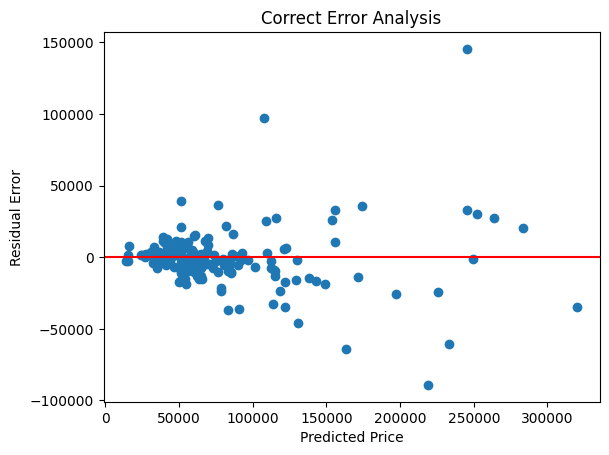

In [108]:
import matplotlib.pyplot as plt

plt.scatter(y_pred_orig,residuals)
plt.axhline(0,color='red')
plt.xlabel('Predicted Price')
plt.ylabel("Residual Error")
plt.title("Correct Error Analysis")
plt.show()

In [109]:
df['price'].describe()

,price
count,893.000000
mean,79907.409854
std,60880.043823
min,9999.000000
25%,44500.000000
50%,61990.000000
75%,90990.000000
max,450039.000000


In [110]:
error_df = pd.DataFrame({
    "actual" : y_test_orig,
    "predicted" : y_pred_orig,
    "error" : residuals
})
error_df.sort_values("error",ascending=False).head()

,actual,predicted,error
739,390914.0,245523.937500,145390.062500
832,205000.0,107750.257812,97249.742188
481,90464.0,51355.812500,39108.187500
213,112990.0,76493.500000,36496.500000
321,209990.0,174226.500000,35763.500000


In [111]:
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np
import pandas as pd

# Define metrics for Linear Regression
lr_r2 = r2_score(actual_lr_orig, pred_lr_orig)
lr_mae = mean_absolute_error(actual_lr_orig, pred_lr_orig)

# Define metrics for Random Forest
rf_r2 = r2_score(actual_rf_orig, pred_rf_orig)
rf_mae = mean_absolute_error(actual_rf_orig, pred_rf_orig)

# Define metrics for Gradient Boosting
gb_r2 = r2_score(actual_gbr_orig, pred_gbr_orig)
gb_mae = mean_absolute_error(actual_gbr_orig, pred_gbr_orig)

# Define metrics for XGBoost (using the last trained XGBoost model's metrics)
xgb_r2 = r2_score(actual, pred)
xgb_mae = mean_absolute_error(actual, pred)

results = [
    ["Linear Regression", lr_r2, lr_mae],
    ["Random Forest", rf_r2, rf_mae],
    ["Gradient Boosting", gb_r2, gb_mae],
    ["XGBoost", xgb_r2, xgb_mae]
]

results_df = pd.DataFrame(
    results,
    columns=["Model", "R2 Score", "MAE"]
)

results_df.sort_values(
    by=["R2 Score", "MAE"],
    ascending=[False, True]
)

,Model,R2 Score,MAE
0,Linear Regression,0.882369,10502.684326
3,XGBoost,0.873124,11591.703420
2,Gradient Boosting,0.854170,11798.281374
1,Random Forest,0.819346,13165.534013


In [112]:
from sklearn.linear_model import LinearRegression

# Impute missing values in the 'cores' column of X before training the final model
X['cores'] = X['cores'].fillna(X['cores'].mean())

final_model = LinearRegression()
final_model.fit(X,y)

LinearRegression()

In [113]:
import joblib

joblib.dump(final_model, 'laptop_price_model.pkl')

['laptop_price_model.pkl']

In [114]:
joblib.dump(X.columns.tolist(),'features.pkl')

['features.pkl']

In [115]:
model = joblib.load('laptop_price_model.pkl')
sample = X.iloc[[0]]
prediction = model.predict(sample)
print("Predicted Price:",np.expm1(prediction)[0])

Predicted Price: 48199.98325747465


In [116]:
import os
print(os.listdir())

['.config', 'laptop_price_model.pkl', 'laptop_data.csv', 'features.pkl', 'sample_data']


In [117]:
features = joblib.load("features.pkl")
print("Total Features:", len(features))
print(features)

Total Features: 111
['spec_rating', 'Ram', 'ROM', 'display_size', 'resolution_width', 'resolution_height', 'warranty', 'cores', 'pixels', 'ppi', 'processor_generation', 'brand_Acer', 'brand_Apple', 'brand_Asus', 'brand_Avita', 'brand_Chuwi', 'brand_Dell', 'brand_Fujitsu', 'brand_Gigabyte', 'brand_HP', 'brand_Honor', 'brand_Huawei', 'brand_Infinix', 'brand_LG', 'brand_Lenovo', 'brand_MSI', 'brand_Microsoft', 'brand_Ninkear', 'brand_Primebook', 'brand_Razer', 'brand_Realme', 'brand_Samsung', 'brand_Tecno', 'brand_Ultimus', 'brand_Vaio', 'brand_Walker', 'brand_Wings', 'brand_Xiaomi', 'brand_Zebronics', 'brand_iBall', 'CPU_10 Cores (2P + 8E), 12 Threads', 'CPU_10 Cores (6P + 4E), 16 Threads', 'CPU_10 Cores (8P + 2E)', 'CPU_10 Cores, 12 Threads', 'CPU_12 Cores', 'CPU_12 Cores (4P + 8E), 16 Threads', 'CPU_14 Cores (6P + 8E)', 'CPU_14 Cores (6P + 8E), 20 Threads', 'CPU_14 Cores, 20 Threads', 'CPU_16 Cores (8P + 8E), 24 Threads', 'CPU_16 Cores, 32 Threads', 'CPU_20 Threads', 'CPU_24 Cores (8P 

Create prediction Function

In [118]:
coef_df = pd.DataFrame({
    "Feature" : X.columns,
    "Coefficient" : abs(final_model.coef_)
})

coef_df = coef_df.sort_values(
    by = "Coefficient",
    ascending = False
)
coef_df.head(20)

,Feature,Coefficient
39,brand_iBall,1.084721
12,brand_Apple,0.745103
62,"CPU_Octa Core, 12 Threads",0.715899
85,OS_Mac High Sierra OS,0.654480
55,"CPU_Dual Core, 2 Threads",0.641605
98,processor_series_Ryzen 3,0.633145
18,brand_Gigabyte,0.590410
31,brand_Samsung,0.559875
26,brand_Microsoft,0.523955
23,brand_LG,0.507132


### Linear Regression was selected as the final model because it achieved the highest R² score (0.882) and the lowest MAE (10502.68).

for website purpose

In [119]:
import pandas as pd

df = pd.read_csv("laptop_data.csv")

# Create 'processor_brand' column
df['processor_brand'] = df['processor'].str.extract(
    r'(Intel|intel|AMD|Amd|Apple|MediaTek)',
    expand = False
)
df['processor_brand'] = df['processor_brand'].replace({
    'intel' : 'Intel',
    'Amd' : 'AMD'
})

# Create 'processor_series' column
df['processor_series'] = df['processor'].str.extract(
    r'(i3|i5|i7|i9|Ryzen 3|Ryzen 5|Ryzen 7|Ryzen 9|Celeron)',
    expand=False
)
df['processor_series'] = df['processor_series'].fillna('Others')

# Create 'gpu_category' column
def gpu_category(gpu):
  gpu = str(gpu)
  if 'RTX' in gpu:
    return 'RTX'
  elif 'GTX' in gpu:
    return 'GTX'
  elif 'Radeon' in gpu:
     return 'Radeon'
  elif 'Iris Xe' in gpu:
    return "Iris Xe"
  elif 'UHD' in gpu:
    return 'UHD'
  else:
    return 'Others'
df['gpu_category'] = df['GPU'].apply(gpu_category)

print(df['brand'].unique())
print(df['processor_brand'].unique())
print(df['processor_series'].unique())
print(df['gpu_category'].unique())

['HP' 'Acer' 'Lenovo' 'Apple' 'Dell' 'Asus' 'Samsung' 'Ultimus'
 'Primebook' 'MSI' 'Infinix' 'Wings' 'Honor' 'Zebronics' 'Xiaomi' 'iBall'
 'Chuwi' 'Realme' 'Avita' 'Walker' 'Huawei' 'Tecno' 'Gigabyte' 'Vaio'
 'Microsoft' 'Fujitsu' 'LG' 'Ninkear' 'Razer' 'AXL']
['AMD' 'Intel' 'Apple' 'MediaTek']
['Ryzen 5' 'i3' 'i5' 'Others' 'i7' 'Celeron' 'Ryzen 3' 'i9' 'Ryzen 7'
 'Ryzen 9']
['Radeon' 'UHD' 'Iris Xe' 'Others' 'RTX' 'GTX']


In [120]:
df['processor_generation'] = df['processor'].str.extract(
    r'(\d+)th Gen',
    expand = False
)

df['processor_generation'] = pd.to_numeric(
    df['processor_generation'],
    errors='coerce'
)

df['processor_generation'] = df['processor_generation'].fillna(0)

print(df['OS'].unique())
print(df['Ram_type'].unique())
print(df['ROM_type'].unique())
print(df['processor_generation'].describe())
print(df['spec_rating'].describe())

['Windows 11 OS' 'Mac OS' 'Android 11 OS' 'DOS OS' 'Windows 10 OS'
 'Windows 10  OS' 'Chrome OS' 'Windows OS' 'Ubuntu OS' 'Mac Catalina OS'
 'DOS 3.0 OS' 'Windows 11  OS' 'Mac High Sierra OS' 'Mac 10.15.3\t OS']
['DDR4' 'LPDDR5' 'DDR5' 'LPDDR4' 'LPDDR5X' 'LPDDR4X' 'DDR3' 'LPDDR4x'
 'Unified' 'DDR4-' 'LPDDR5x' 'DDR']
['SSD' 'Hard-Disk']
count    893.000000
mean       9.441209
std        3.916758
min        0.000000
25%        7.000000
50%       11.000000
75%       12.000000
max       13.000000
Name: processor_generation, dtype: float64
count    893.000000
mean      69.379026
std        5.541555
min       60.000000
25%       66.000000
50%       69.323529
75%       71.000000
max       89.000000
Name: spec_rating, dtype: float64


In [121]:
print(df['warranty'].describe())

count    893.000000
mean       1.079507
std        0.326956
min        0.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        3.000000
Name: warranty, dtype: float64


In [122]:
print(len(features))
print(features)

111
['spec_rating', 'Ram', 'ROM', 'display_size', 'resolution_width', 'resolution_height', 'warranty', 'cores', 'pixels', 'ppi', 'processor_generation', 'brand_Acer', 'brand_Apple', 'brand_Asus', 'brand_Avita', 'brand_Chuwi', 'brand_Dell', 'brand_Fujitsu', 'brand_Gigabyte', 'brand_HP', 'brand_Honor', 'brand_Huawei', 'brand_Infinix', 'brand_LG', 'brand_Lenovo', 'brand_MSI', 'brand_Microsoft', 'brand_Ninkear', 'brand_Primebook', 'brand_Razer', 'brand_Realme', 'brand_Samsung', 'brand_Tecno', 'brand_Ultimus', 'brand_Vaio', 'brand_Walker', 'brand_Wings', 'brand_Xiaomi', 'brand_Zebronics', 'brand_iBall', 'CPU_10 Cores (2P + 8E), 12 Threads', 'CPU_10 Cores (6P + 4E), 16 Threads', 'CPU_10 Cores (8P + 2E)', 'CPU_10 Cores, 12 Threads', 'CPU_12 Cores', 'CPU_12 Cores (4P + 8E), 16 Threads', 'CPU_14 Cores (6P + 8E)', 'CPU_14 Cores (6P + 8E), 20 Threads', 'CPU_14 Cores, 20 Threads', 'CPU_16 Cores (8P + 8E), 24 Threads', 'CPU_16 Cores, 32 Threads', 'CPU_20 Threads', 'CPU_24 Cores (8P + 16E)', 'CPU_24

In [123]:
print(model.predict(sample))

[10.7831347]
